## California Housing Price Prediction

## 1. Import Libraries

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

## 2. Load Dataset

In [2]:
fetch_california_housing()

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [3]:
df = fetch_california_housing()

In [4]:
dataset = pd.DataFrame(df.data)

In [5]:
dataset

,0,1,2,3,4,5,6,7
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [6]:
dataset.columns=df.feature_names

In [7]:
dataset

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [8]:
table = fetch_california_housing(as_frame=True)

df_joined = table.frame

In [9]:
df_joined # this is the experimenting df with target variable

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


## 3.Exploratory data analysis

### 3.a. Distribution of target variable

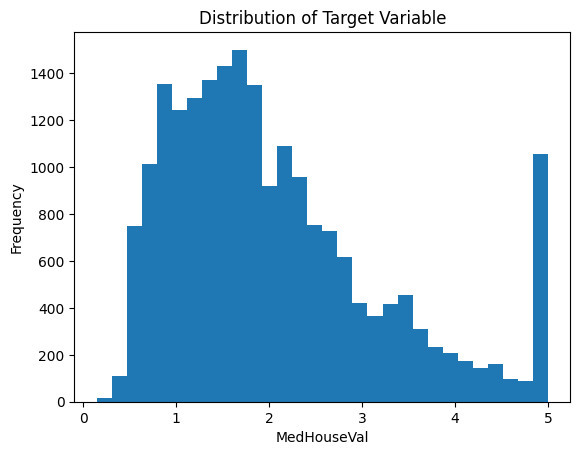

In [10]:
plt.hist(df_joined["MedHouseVal"], bins=30)

plt.xlabel("MedHouseVal")
plt.ylabel("Frequency")
plt.title("Distribution of Target Variable")


plt.show()

### 3.b. Checking for nulls

In [12]:
df_joined.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

### 3.c. Check for correlation 

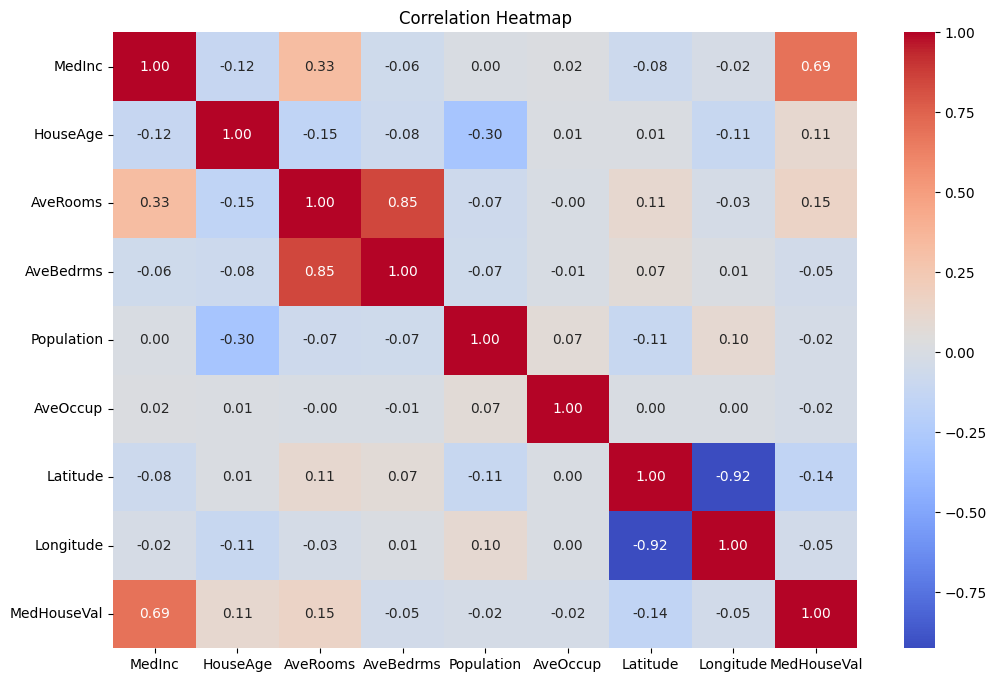

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df_joined.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### 3.d. Scatter plots to see the distribution of variables

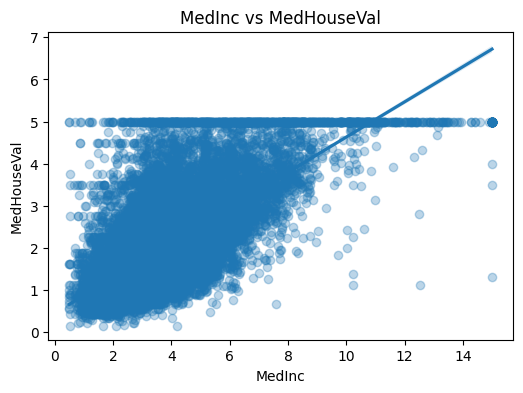

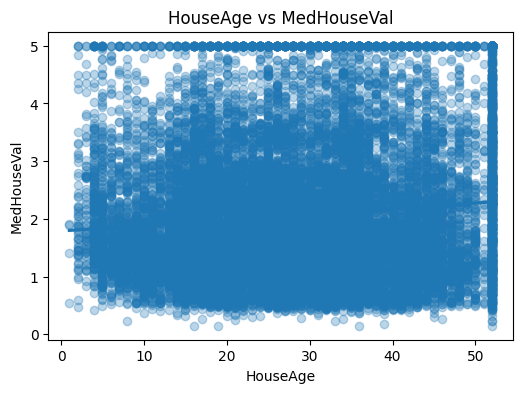

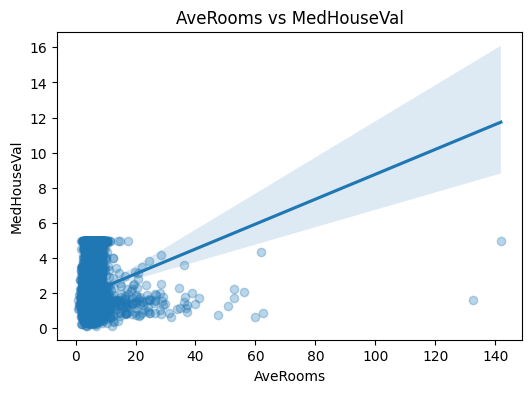

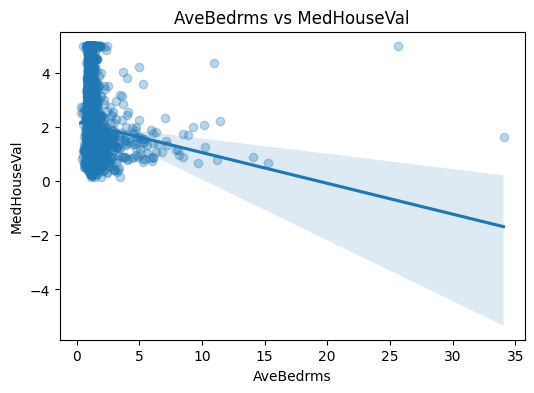

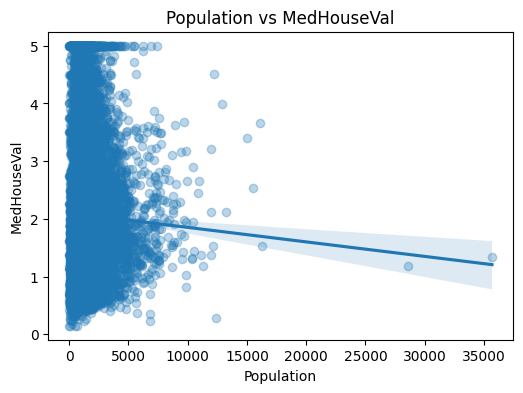

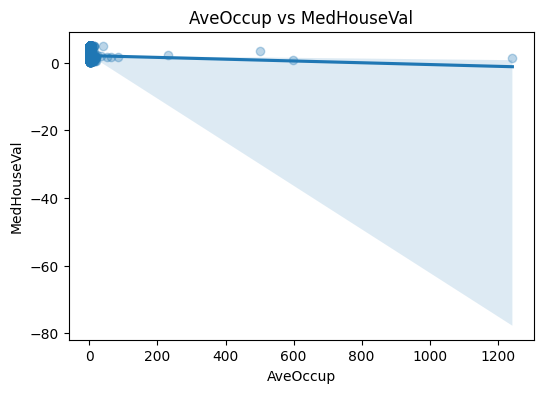

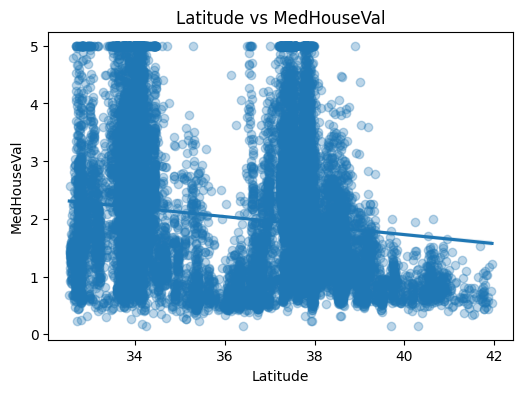

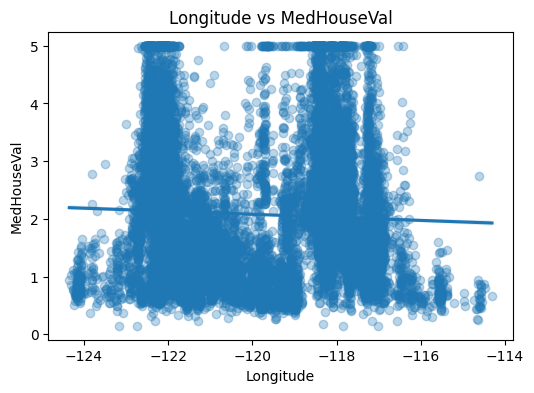

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

features = df_joined.columns.drop("MedHouseVal")

for col in features:
    plt.figure(figsize=(6,4))

    sns.regplot(
        x=df_joined[col],
        y=df_joined["MedHouseVal"],
        scatter_kws={"alpha":0.3}
    )

    plt.title(f"{col} vs MedHouseVal")
    plt.show()

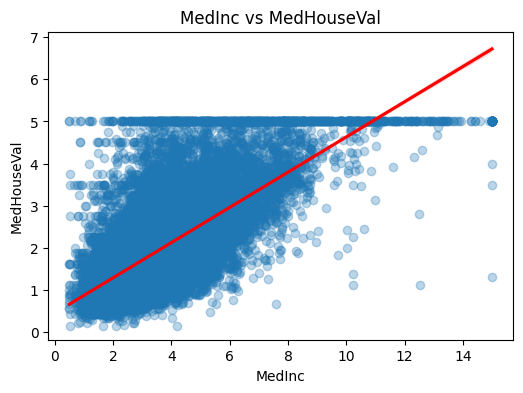

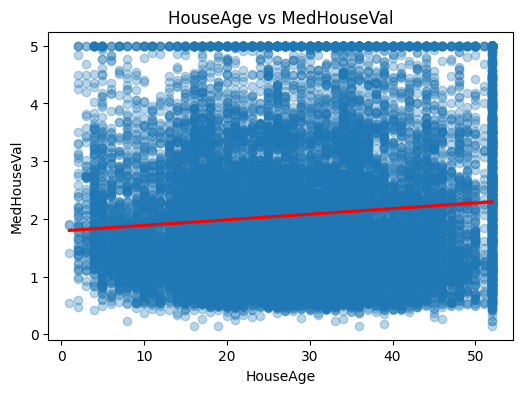

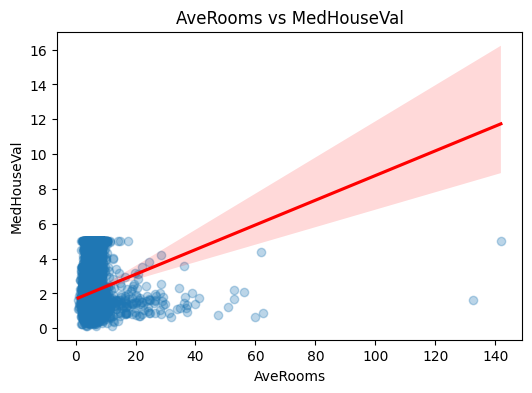

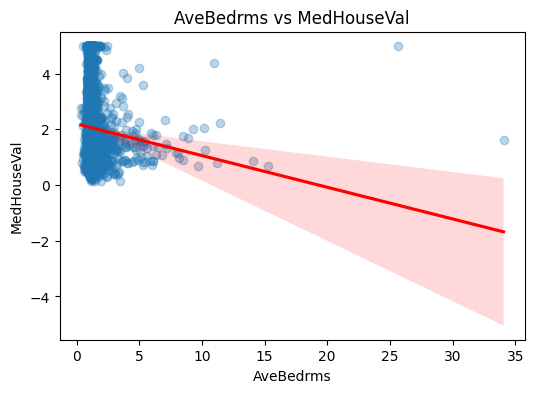

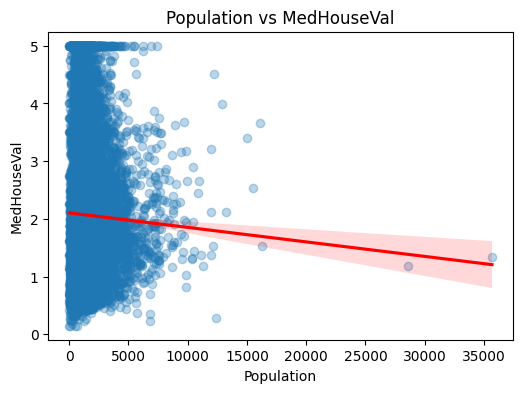

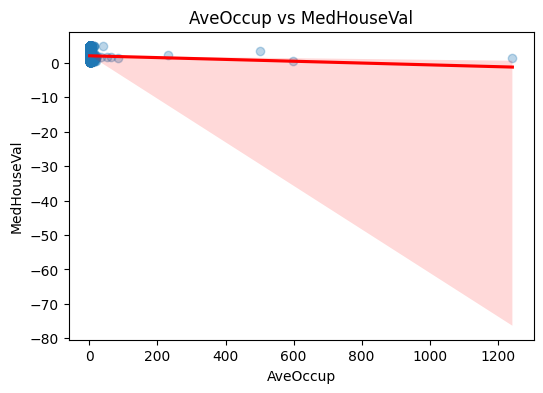

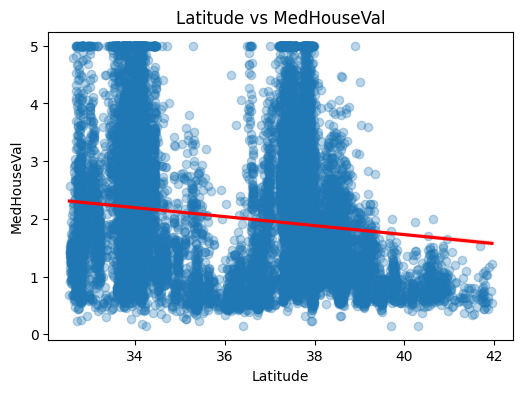

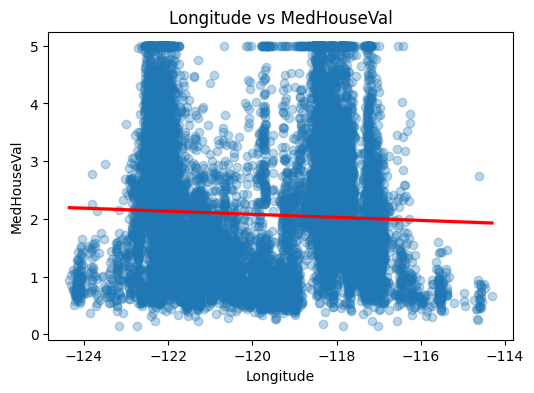

In [17]:


features = df_joined.columns.drop("MedHouseVal")

for col in features:
    plt.figure(figsize=(6,4))

    sns.regplot(
        x=df_joined[col],
        y=df_joined["MedHouseVal"],
        scatter_kws={"alpha": 0.3},
        line_kws={"color": "red"}
    )

    plt.title(f"{col} vs MedHouseVal")

    plt.show()

In [18]:
# 1)Not able to see the distribution properly. Latitudes and Longitudes can't be normalized because these are coordinates of locations
# 2) no null values
# 3) strong correlation between avgrooms and avgbedrooms, longituded and latitudes.

In [19]:
### Histplot to check the normal distribution for regression

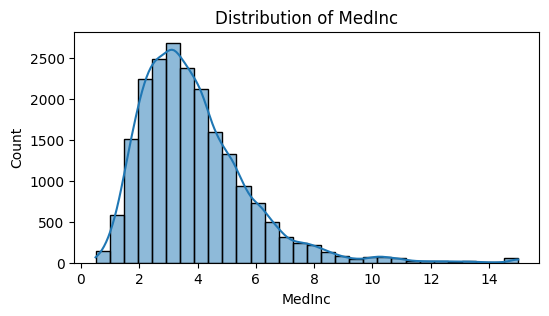

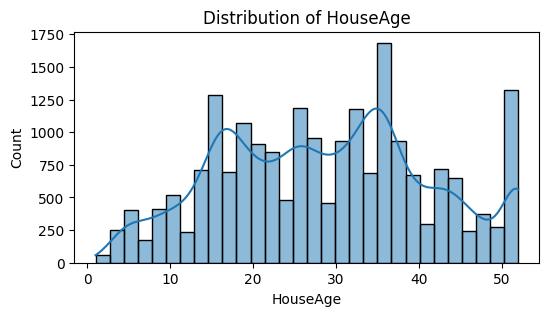

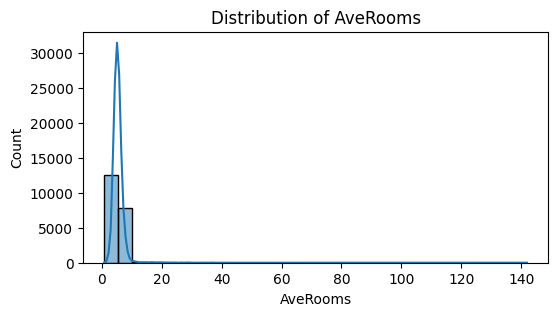

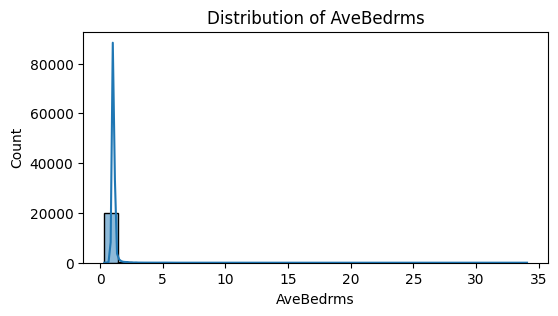

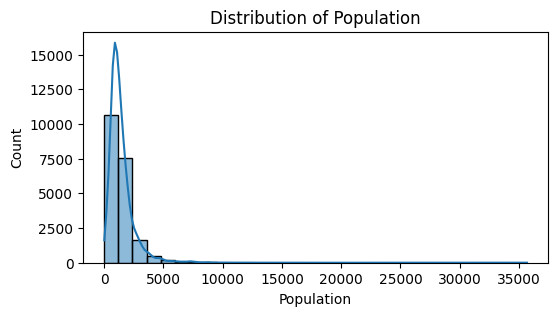

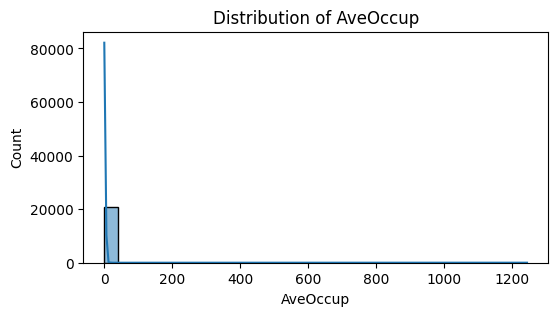

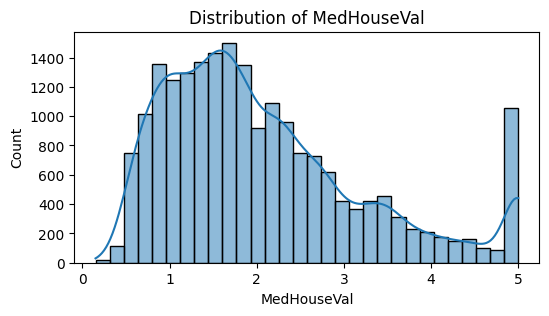

In [20]:
features = df_joined.columns.drop([
    "Latitude",
    "Longitude"
])

for col in features:
    
    plt.figure(figsize=(6,3))

    sns.histplot(
        df_joined[col],
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {col}")

    plt.show()

In [21]:
# 1) medInc, avg rooms, avebedrms, population have right skewed shape so aply log transform 

### 3.e. log tranform and check if it's normal distribution using Q-Q plot

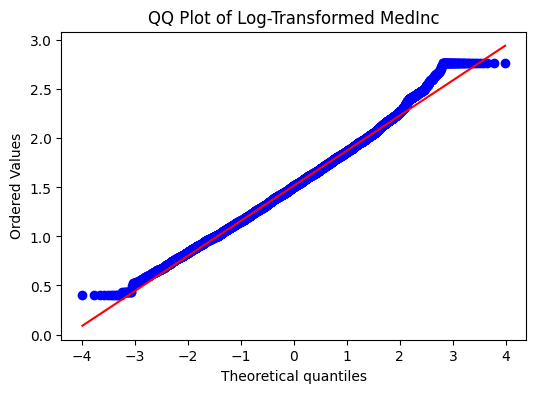

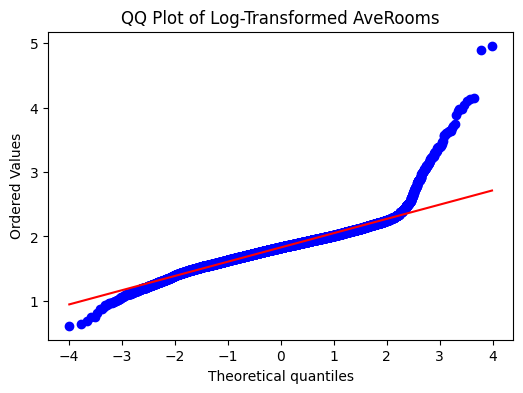

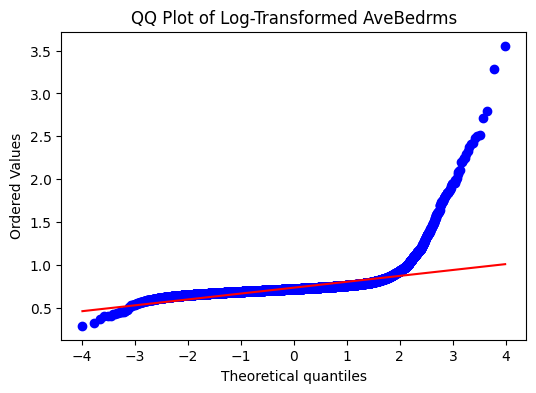

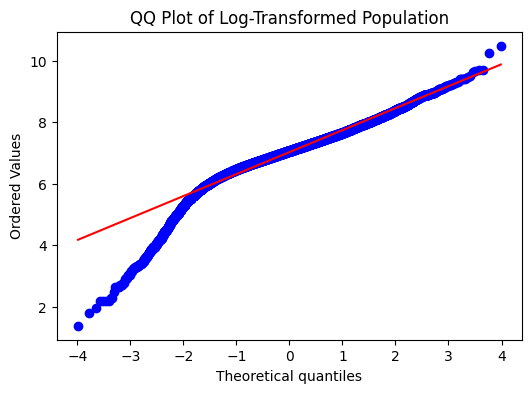

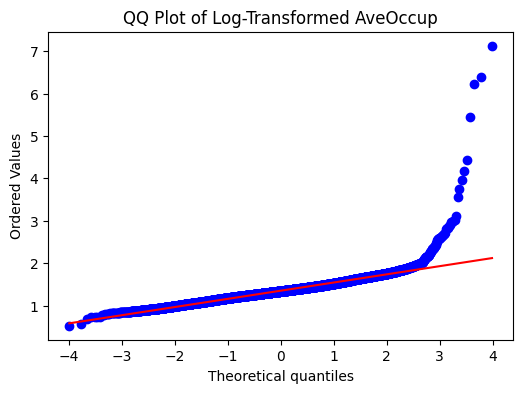

In [22]:
# import numpy as np
# import matplotlib.pyplot as plt
import scipy.stats as stats

cols = [
    "MedInc",
    "AveRooms",
    "AveBedrms",
    "Population",
    "AveOccup"
]

for col in cols:

    # log transform
    log_data = np.log1p(df_joined[col])

    # QQ plot
    plt.figure(figsize=(6,4))

    stats.probplot(
        log_data,
        dist="norm",
        plot=plt
    )

    plt.title(f"QQ Plot of Log-Transformed {col}")

    plt.show()

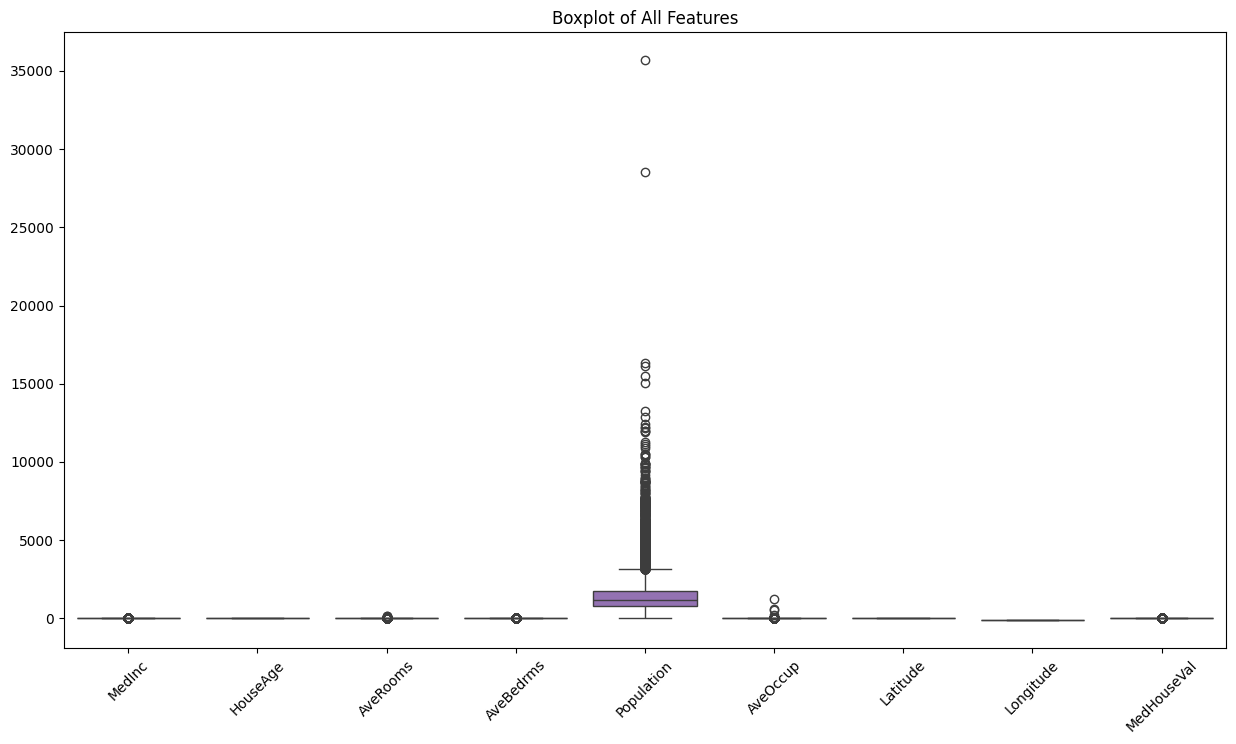

In [23]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df_joined)

plt.xticks(rotation=45)

plt.title("Boxplot of All Features")

plt.show()

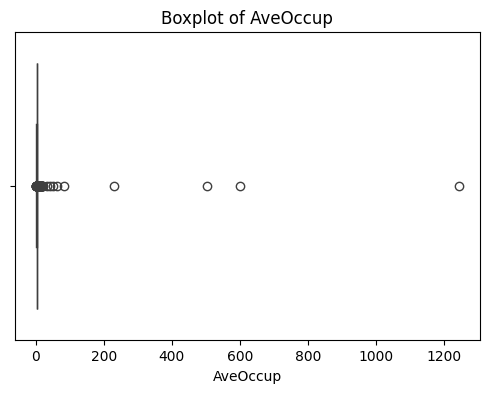

In [24]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x=df_joined["AveOccup"]
)

plt.title("Boxplot of AveOccup")

plt.show()

In [25]:
df_joined["AveOccup"].describe()

count    20640.000000
mean         3.070655
std         10.386050
min          0.692308
25%          2.429741
50%          2.818116
75%          3.282261
max       1243.333333
Name: AveOccup, dtype: float64

In [26]:
corr_matrix = df_joined.corr()

print(corr_matrix)

               MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc       1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge    -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms     0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms   -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population   0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup     0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude    -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude   -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   
MedHouseVal  0.688075  0.105623  0.151948  -0.046701   -0.024650 -0.023737   

             Latitude  Longitude  MedHouseVal  
MedInc      -0.079809  -0.015176     0.688075  
HouseAge     0.011173  -0.108197     0.105623  
AveRooms     0.106389  -0.027540     0.151948  
AveBedrms    0.069721   0.0

In [27]:
# Avg Occ still has outliers. So removing outliers using clip upper limit above 0.99 percentile

In [28]:
X = dataset
y = df.target

In [29]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [30]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

      Feature         VIF
0      MedInc   11.511140
1    HouseAge    7.195917
2    AveRooms   45.993601
3   AveBedrms   43.590314
4  Population    2.935745
5    AveOccup    1.095243
6    Latitude  559.874071
7   Longitude  633.711654


In [32]:
# scalar = StandardScaler()

In [33]:
cols = [
    "MedInc",
    "AveRooms",
    "AveBedrms",
    "Population"
]

for col in cols:
    
    df_joined[col] = np.log1p(df_joined[col])

### 3.f.Clip extreme outiers in avg occ and apply on X dataset

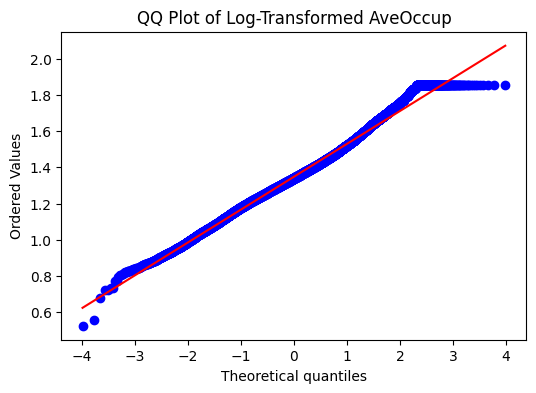

In [34]:
# Step 1: clip extreme outliers
upper_limit = df_joined["AveOccup"].quantile(0.99)

df_joined["AveOccup"] = np.clip(
    df_joined["AveOccup"],
    None,
    upper_limit
)

# Step 2: log transform
df_joined["AveOccup"] = np.log1p(
    df_joined["AveOccup"]
)

# Step 3: QQ plot
plt.figure(figsize=(6,4))

stats.probplot(
    df_joined["AveOccup"],
    dist="norm",
    plot=plt
)

plt.title("QQ Plot of Log-Transformed AveOccup")

plt.show()

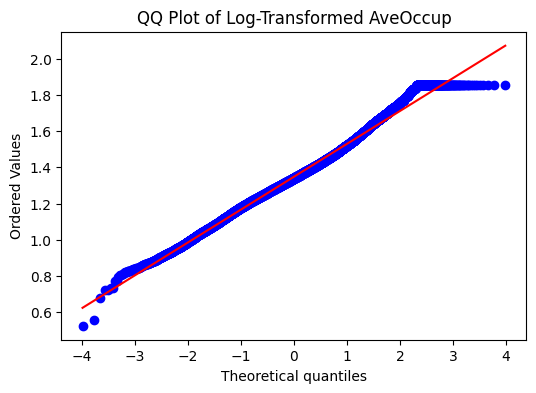

In [35]:
cols = [
    "MedInc",
    "AveRooms",
    "AveBedrms",
    "Population"
]

# Apply log transform
for col in cols:
    
    X[col] = np.log1p(X[col])

# Handle AveOccup separately

# Step 1: clip outliers
upper_limit = X["AveOccup"].quantile(0.99)

X["AveOccup"] = np.clip(
    X["AveOccup"],
    None,
    upper_limit
)

# Step 2: log transform
X["AveOccup"] = np.log1p(
    X["AveOccup"]
)

# Step 3: QQ Plot
plt.figure(figsize=(6,4))

stats.probplot(
    X["AveOccup"],
    dist="norm",
    plot=plt
)

plt.title("QQ Plot of Log-Transformed AveOccup")

plt.show()

In [ ]:
### 4) Train Test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

### 3.e. Scaling using standard scalar

In [37]:


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
# X_train=scalar.fit_transform(X_train)

In [39]:
# X_test=scalar.transform(X_test)

In [40]:
X_train

array([[-2.32671831, -0.75868455, -1.70996758, ..., -0.33486553,
        -0.78315293,  0.65090402],
       [ 0.37601183,  0.3523991 ,  0.61420795, ..., -0.71700275,
         0.8475975 , -1.31911678],
       [-0.00936312,  1.06666717, -0.29345108, ...,  1.78586924,
        -0.87218816,  0.66087881],
       ...,
       [-0.41385616,  0.59048846, -0.95908067, ...,  0.64779272,
        -0.75972261,  0.60103008],
       [ 1.07809037, -1.07613702,  0.73548178, ...,  0.45051103,
         0.90383028, -1.18445713],
       [-0.68049826,  1.86029835, -1.49482338, ..., -1.17075528,
         0.9928655 , -1.41387727]])

## Modelling and evaluation

### 5)Linear regression

In [41]:
regression = LinearRegression()
regression.fit(X_train,y_train)

LinearRegression()

In [42]:
mse = cross_val_score(regression, X_train, y_train, scoring = 'neg_mean_squared_error', cv= 5)

In [43]:
np.mean(mse)

np.float64(-0.48168387755333786)

In [44]:
reg_pred = regression.predict(X_test)

In [45]:
reg_pred

array([0.17300857, 1.86045844, 3.52049091, ..., 1.13350369, 1.55357074,
       2.50004547])

C:\Users\shari\AppData\Local\Temp\ipykernel_21688\1726680495.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(reg_pred - y_test, kde=True)


<Axes: ylabel='Density'>

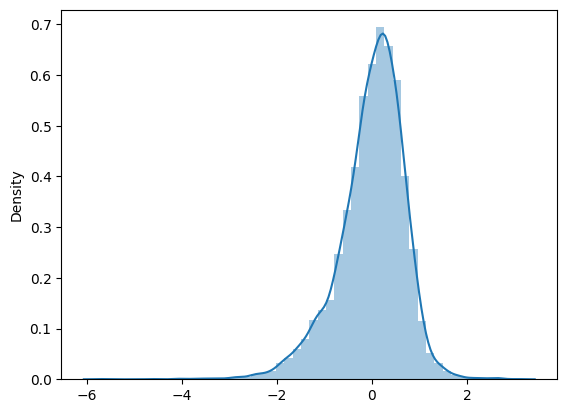

In [46]:
import seaborn as sns
sns.distplot(reg_pred - y_test, kde=True)

In [47]:
score = r2_score(y_test, reg_pred)

In [48]:
score

0.6320889262711444

In [49]:
from sklearn.metrics import r2_score

# train predictions
y_train_pred = regression.predict(X_train)

# test predictions
y_test_pred = regression.predict(X_test)

# train R2
train_r2 = r2_score(y_train, y_train_pred)

# test R2
test_r2 = r2_score(y_test, y_test_pred)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.638600626920124
Test R2: 0.6320889262711444


### 6 Ridge Regression

In [50]:
ridge_regressor = Ridge()

In [51]:
parameters= {'alpha': [1,2,3,4,10,20,30,40,50,60,70,80,90]}
ridgecv = GridSearchCV(ridge_regressor,parameters,scoring ='neg_mean_squared_error', cv= 5)
ridgecv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 3, 4, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [52]:
print(ridgecv.best_params_)

{'alpha': 1}


In [53]:
print(ridgecv.best_score_)

-0.4816835276724511


In [54]:
ridge_pred = ridgecv.predict(X_test)

C:\Users\shari\AppData\Local\Temp\ipykernel_21688\4142520672.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(ridge_pred - y_test, kde=True)


<Axes: ylabel='Density'>

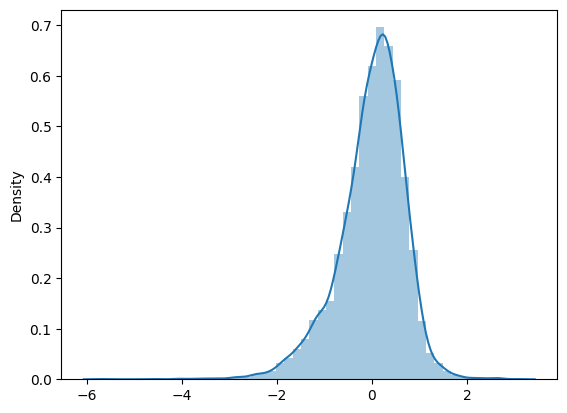

In [55]:
sns.distplot(ridge_pred - y_test, kde=True)

### 7 Lasso Regression

In [56]:
lasso_reg = Lasso()

In [57]:
parameters= {'alpha': [1,2,3,4,10,20,30,40,50,60,70,80,90]}
lassocv = GridSearchCV(lasso_reg,parameters,scoring ='neg_mean_squared_error', cv= 5)
lassocv .fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1, 2, 3, 4, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [58]:
print(lassocv.best_params_)

{'alpha': 1}


In [59]:
print(lassocv.best_score_)

-1.3311092498802068


In [60]:
Lasso_pred = lassocv.predict(X_test)

C:\Users\shari\AppData\Local\Temp\ipykernel_21688\2511262897.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Lasso_pred - y_test, kde=True)


<Axes: ylabel='Density'>

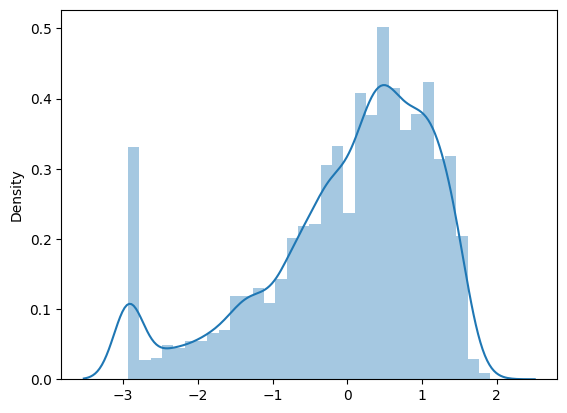

In [61]:
sns.distplot(Lasso_pred - y_test, kde=True)

### 8 Random Forest Regressor

In [62]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42)

rf.fit(X_train, y_train)



RandomForestRegressor(max_depth=10, min_samples_leaf=5, random_state=42)

In [63]:
rf_pred = rf.predict(X_test)

C:\Users\shari\AppData\Local\Temp\ipykernel_21688\3591369124.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(rf_pred - y_test, kde=True)


<Axes: ylabel='Density'>

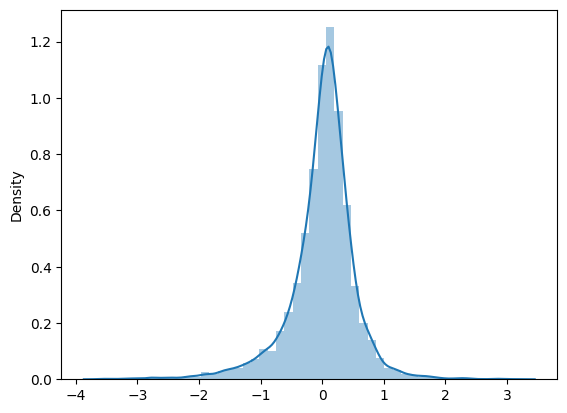

In [64]:
sns.distplot(rf_pred - y_test, kde=True)

In [65]:
score = r2_score(y_test,rf_pred)

In [66]:
score

0.7757222792677463

In [67]:
from sklearn.metrics import r2_score

# predictions
rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

# R2 scores
train_r2 = r2_score(y_train, rf_train_pred)
test_r2 = r2_score(y_test, rf_test_pred)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.8558039412491014
Test R2: 0.7757222792677463


### 9 Random forest using grid search

In [81]:
rf = RandomForestRegressor(
    random_state=42
)

params = {
    "n_estimators": [50, 100],
    "max_depth": [8, 10],
    "min_samples_leaf": [3, 5]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [8, 10], 'min_samples_leaf': [3, 5],
                         'n_estimators': [50, 100]},
             scoring='r2')

In [69]:
print(grid.best_params_)

{'max_depth': 10, 'min_samples_leaf': 3, 'n_estimators': 100}


In [70]:
print(grid.best_score_)

0.7733242588910807


In [71]:
best_rf = grid.best_estimator_

In [72]:
print(best_rf.score(X_train, y_train))
print(best_rf.score(X_test, y_test))

0.8654317985231536
0.7767042045329533


### 10 XGBoost

In [74]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [75]:
print("Train R2:", xgb.score(X_train, y_train))
print("Test R2:", xgb.score(X_test, y_test))

Train R2: 0.8659266305281262
Test R2: 0.8189985966049255


In [78]:
xgb_pred = xgb.predict(X_test)

# MSE
mse = mean_squared_error(
    y_test,
    xgb_pred
)

print("MSE:", mse)

MSE: 0.241200988708015


In [79]:
# Therefore XG boost is performing very well than regression models
